# Ti-6Al-4V Cutting Thermal Model

Flash temperature, surface and subsurface temperature, and thermally induced residual stress for orthogonal cutting of Ti-6Al-4V. All physics lives in `model.py`; this notebook runs it and shows the same results as the Streamlit UI (`app.py`).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from model import (TI64, KIENZLE_TI64, kienzle_force, solve, solve_2d, residual_stress,
                   force_vs_feed, flash_vs_speed, critical_speed, critical_speed_fit)

## Inputs

In [2]:
v_m_min = 60.0   # cutting speed (m/min)
h_mm    = 0.05   # feed / uncut chip thickness (mm)
b_um    = 200.0  # contact half-width b (um); contact length = 2b
w_mm    = 3.0    # width of cut (mm)
T0      = 20.0   # ambient temperature (deg C)

SWEEP_FEEDS = (0.01, 0.05, 0.10)  # feeds (mm) for the flash-temperature-vs-speed lines

## Cutting force (Kienzle fit)

$F_c = k_c\,h\,w,\qquad k_c = C\,h^{\,n}$ with $C = 1792.69$ N/mm², $n = -0.1167$ (fit to `ref/Cutting Force Data.xlsx`).

In [3]:
Fc = float(kienzle_force(h_mm, w_mm))
print(f"Kienzle C = {KIENZLE_TI64[0]}, n = {KIENZLE_TI64[1]}")
print(f"Fc = {Fc:.1f} N")

Kienzle C = 1792.69, n = -0.11672
Fc = 381.5 N


## Flash temperature

$Pe = \dfrac{v\,\rho\,b\,c_p}{2k}$, with $k(T)$ and $c_p(T)$ evaluated at the current guess.

- $Pe < 5$: $\;\Delta T = 0.159\,C_4\,\dfrac{2F_c}{\rho c_p w b},\quad C_4 = 0.00527Pe^3 - 0.192Pe^2 + 2.39Pe$
- $Pe \ge 5$: $\;\Delta T = 0.399\,\dfrac{2F_c v}{k w}\sqrt{\dfrac{k}{\rho c_p v b}}$

Fixed-point iteration with damping $T_{guess} \leftarrow (\Delta T + T_{guess})/2$, starting from $T_{guess} = (T_0 + T_{melt})/2$.

Peak surface T       = 831.8 C
Flash rise dT        = 811.8 K
Peclet number        = 16.504
k, cp at convergence = 21.75 W/(m K), 797.9 J/(kg K)
Density              = 4500 kg/m^3
Initial guess        = 840 C   (T_melt = 1660 C)
Iterations           = 5  (converged: True)


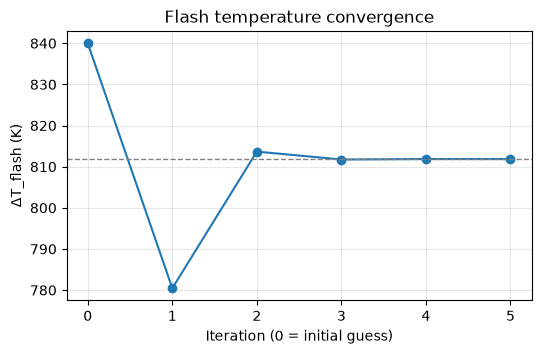

In [4]:
r = solve(v_m_min, Fc, w_mm, b_um, T0)
print(f"Peak surface T       = {T0 + r.T_flash:.1f} C")
print(f"Flash rise dT        = {r.T_flash:.1f} K")
print(f"Peclet number        = {r.Pe:.3f}")
print(f"k, cp at convergence = {r.k:.2f} W/(m K), {r.cp:.1f} J/(kg K)")
print(f"Density              = {TI64['rho']:g} kg/m^3")
print(f"Initial guess        = {r.history[0]:.0f} C   (T_melt = {TI64['T_melt']:g} C)")
print(f"Iterations           = {r.iterations}  (converged: {r.converged})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(len(r.history)), r.history, "o-")
ax.axhline(r.T_flash, color="gray", ls="--", lw=1)
ax.set(title="Flash temperature convergence", xlabel="Iteration (0 = initial guess)", ylabel="ΔT_flash (K)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(alpha=0.3)

## Surface temperature (1D)

Moving band source (Liu 2004), with $P_\pm = Pe\,(x/b \pm 1)/2$; for $-1 < x/b < 1$:

$f(x) = (x/b+1)\,e^{P_+}\left[K_0(P_+) + K_1(P_+)\right] + (1-x/b)\,e^{P_-}\left[K_0(-P_-) - K_1(-P_-)\right]$

(the outer branches swap the sign convention). The shape is normalized to peak 1, then $T(x) = T_0 + \Delta T\, f(x)/f_{max}$.

Peak at x/b = 0.91


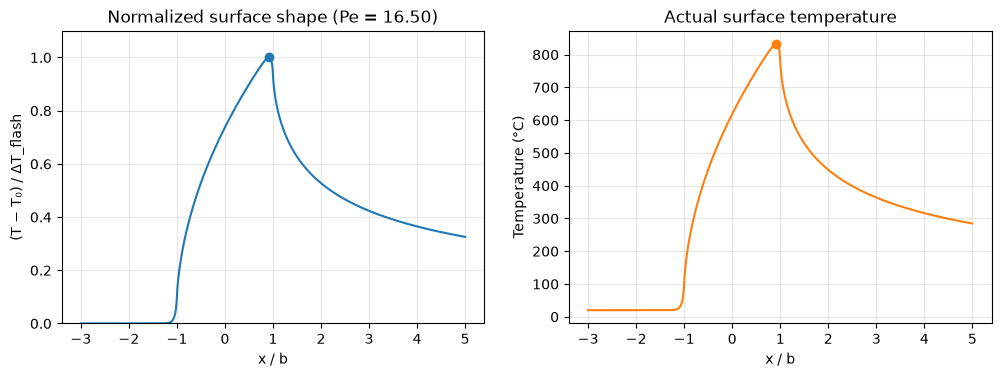

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
a1.plot(r.x_over_b, r.shape)
a1.plot(r.peak_x_over_b, 1.0, "o", color="C0")
a1.set(title=f"Normalized surface shape (Pe = {r.Pe:.2f})", xlabel="x / b", ylabel="(T − T₀) / ΔT_flash", ylim=(0, 1.1))
a2.plot(r.x_over_b, r.T_actual_C, color="C1")
a2.plot(r.peak_x_over_b, T0 + r.T_flash, "o", color="C1")
a2.set(title="Actual surface temperature", xlabel="x / b", ylabel="Temperature (°C)")
for a in (a1, a2):
    a.grid(alpha=0.3)
print(f"Peak at x/b = {r.peak_x_over_b:.2f}")

## Subsurface temperature and residual stress (2D)

$T(x, z) = \max\!\left(T_0,\; T(x)\left[1 - \operatorname{erf}\!\left(\dfrac{z}{\sqrt{4\alpha t}}\right)\right]\right),\quad \alpha = \dfrac{k}{\rho c_p},\; t = \dfrac{2b}{v}$

Critical temperature $T_{crit}$: lowest $T$ where $\dfrac{E\,\alpha_{th}\,(T - T_0)}{1-\nu} > \sigma_y(T)$. Above it, $\sigma_{RS} = 2.8788\,T - 1365.2$ MPa (tensile +); below it, $\sigma_{RS} = 0$.

Critical T (yield)  = 479.6 C
Surface RS at flank = 951.6 MPa
Yielded depth       = 35.6 um


[Text(0.5, 1.0, 'Subsurface temperature with residual stress'),
 Text(0.5, 0, 'x / b'),
 Text(0, 0.5, 'z / b (depth)'),
 (0.9, 0.0)]

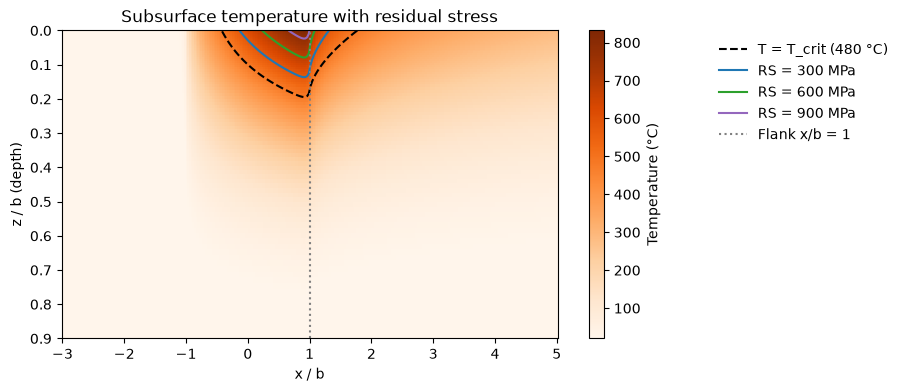

In [6]:
X = np.linspace(-3.0, 5.0, 300)
Z = 4.0 * np.linspace(0.0, 1.0, 200) ** 2   # fine near the surface, where RS lives
r2 = solve_2d(v_m_min, Fc, w_mm, b_um, T0, x_over_b=X, z_over_b=Z)
Tc = r2.T_critical_C
rs_field = residual_stress(r2.T_field_C, Tc)
yielded = r2.z_over_b[r2.residual_stress_MPa > 0]

print(f"Critical T (yield)  = {Tc:.1f} C")
print(f"Surface RS at flank = {r2.residual_stress_MPa[0]:.1f} MPa")
print(f"Yielded depth       = {yielded.max() * b_um if yielded.size else 0:.1f} um")

fig, ax = plt.subplots(figsize=(8, 4))
mesh = ax.pcolormesh(X, Z, r2.T_field_C, cmap="Oranges", shading="auto")
fig.colorbar(mesh, ax=ax, label="Temperature (°C)")
if rs_field.max() > 0:
    ax.contour(X, Z, r2.T_field_C, levels=[Tc], colors="k", linestyles="dashed")
    ax.plot([], [], "k--", label=f"T = T_crit ({Tc:.0f} °C)")
    for color, level in zip(["C0", "C2", "C4", "C9"], MaxNLocator(4).tick_values(0, rs_field.max())[1:-1]):
        ax.contour(X, Z, rs_field, levels=[level], colors=[color])
        ax.plot([], [], color=color, label=f"RS = {level:.0f} MPa")
ax.axvline(1.0, color="gray", ls=":")
ax.plot([], [], ":", color="gray", label="Flank x/b = 1")
ax.legend(loc="upper left", bbox_to_anchor=(1.3, 1.0), frameon=False)
ax.set(title="Subsurface temperature with residual stress", xlabel="x / b", ylabel="z / b (depth)", ylim=(0.9, 0))

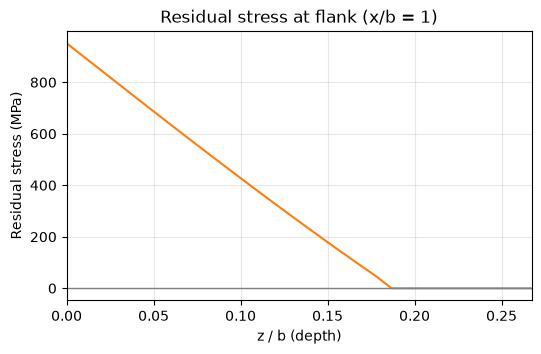

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(r2.z_over_b, r2.residual_stress_MPa, color="C1")
ax.axhline(0, color="gray", lw=1)
ax.set(title="Residual stress at flank (x/b = 1)", xlabel="z / b (depth)", ylabel="Residual stress (MPa)",
       xlim=(0, 1.5 * yielded.max() if yielded.size else 1.0))
ax.grid(alpha=0.3)

## Machining sweeps

Force from the Kienzle fit at fixed $b$ and $w$. The critical speed is the lowest $v$ at which the flank ($x/b = 1$) surface temperature exceeds $T_{crit}$, which gives tensile surface RS. It is fitted as $v_{crit} = a\,h^{\,n}$.

Critical speed at h = 0.05 mm: 1.559 m/s
Critical speed fit: v = 0.01017 * h^-1.684  (v in m/s, h in mm)


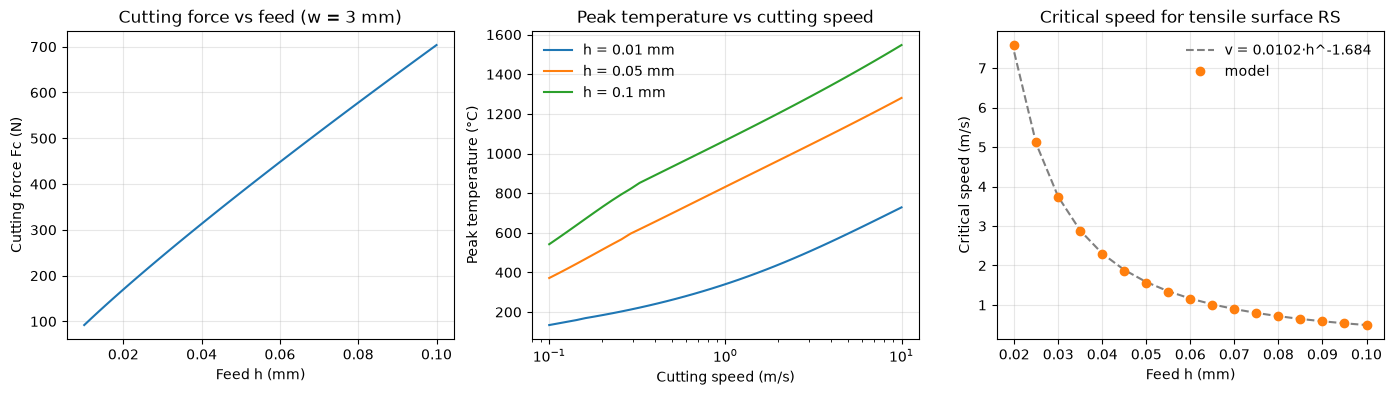

In [8]:
h = np.linspace(0.01, 0.10, 50)
v = np.geomspace(0.1, 10.0, 40)
hc = np.linspace(0.01, 0.10, 19)
vc = np.array([critical_speed(x, w_mm, b_um, T0) for x in hc])
ok = np.isfinite(vc)
a, n = critical_speed_fit(hc, vc)
v_crit = critical_speed(h_mm, w_mm, b_um, T0)

print(f"Critical speed at h = {h_mm} mm: " + (f"{v_crit:.3f} m/s" if np.isfinite(v_crit) else "> 10 m/s"))
print(f"Critical speed fit: v = {a:.4g} * h^{n:.3f}  (v in m/s, h in mm)")

fig, axs = plt.subplots(1, 3, figsize=(17, 4))
axs[0].plot(h, force_vs_feed(h, w_mm))
axs[0].set(title=f"Cutting force vs feed (w = {w_mm:g} mm)", xlabel="Feed h (mm)", ylabel="Cutting force Fc (N)")
for hf in SWEEP_FEEDS:
    axs[1].plot(v, flash_vs_speed(v, hf, w_mm, b_um, T0), label=f"h = {hf:g} mm")
axs[1].set(title="Peak temperature vs cutting speed", xlabel="Cutting speed (m/s)", ylabel="Peak temperature (°C)", xscale="log")
axs[1].legend(frameon=False)
axs[2].plot(hc[ok], a * hc[ok] ** n, "--", color="gray", label=f"v = {a:.3g}·h^{n:.3f}")
axs[2].plot(hc[ok], vc[ok], "o", color="C1", label="model")
axs[2].set(title="Critical speed for tensile surface RS", xlabel="Feed h (mm)", ylabel="Critical speed (m/s)")
axs[2].legend(frameon=False)
for ax in axs:
    ax.grid(alpha=0.3)